# Quickstart `doped` Tutorial

```{tip}
You can run this notebook interactively through [Google Colab](https://colab.research.google.com/github/SMTG-Bham/doped/blob/develop/examples/quickstart_tutorial.ipynb) or [Binder](https://mybinder.org/v2/gh/SMTG-Bham/doped/develop?urlpath=tree/examples/quickstart_tutorial.ipynb) – just click the links!
If running on Colab, then you'll need to run `!pip install doped` in a cell to install the package, and `!git clone https://github.com/SMTG-Bham/doped` to download the example data (and update paths in the code cells accordingly).
```

This notebook provides a condensed walkthrough of the core `doped` workflow for point defect calculations in crystalline materials, going from **defect generation → input file writing → parsing → formation energy plotting → thermodynamic analysis**.

Each section includes a pointer to the relevant detailed tutorial for more information, and CdTe is used as the example host material throughout.

## 1. Defect Generation

The `DefectsGenerator` class generates the symmetry-inequivalent point defects (vacancies, antisites, and interstitials) for a given host structure, with automatic charge state guessing. See the [defect generation tutorial](https://doped.readthedocs.io/en/latest/generation_tutorial.html) for full details.

In [15]:
from doped.generation import DefectsGenerator

# use the relaxed primitive cell of CdTe (can also load as a pymatgen Structure, and input)
defect_gen = DefectsGenerator("CdTe/relaxed_primitive_POSCAR")

Guessing charge states: 100.0%|██████████| [00:01,  56.87it/s]                                     

Vacancies    Guessed Charges    Conv. Cell Coords    Wyckoff
-----------  -----------------  -------------------  ---------
v_Cd         [+1,0,-1,-2]       [0.000,0.000,0.000]  4a
v_Te         [+2,+1,0,-1]       [0.250,0.250,0.250]  4c

Substitutions    Guessed Charges        Conv. Cell Coords    Wyckoff
---------------  ---------------------  -------------------  ---------
Cd_Te            [+4,+3,+2,+1,0]        [0.250,0.250,0.250]  4c
Te_Cd            [+2,+1,0,-1,-2,-3,-4]  [0.000,0.000,0.000]  4a

Interstitials    Guessed Charges        Conv. Cell Coords    Wyckoff
---------------  ---------------------  -------------------  ---------
Cd_i_C3v         [+2,+1,0]              [0.625,0.625,0.625]  16e
Cd_i_Td_Cd2.83   [+2,+1,0]              [0.750,0.750,0.750]  4d
Cd_i_Td_Te2.83   [+2,+1,0]              [0.500,0.500,0.500]  4b
Te_i_C3v         [+4,+3,+2,+1,0,-1,-2]  [0.625,0.625,0.625]  16e
Te_i_Td_Cd2.83   [+4,+3,+2,+1,0,-1,-2]  [0.750,0.750,0.750]  4d
Te_i_Td_Te2.83   [+4,+3,+2,+1,0,

## 2. Writing Input Files

The `DefectsSet` class takes a `DefectsGenerator` (or individual defect entries) and prepares `VASP` input files for all defect supercell calculations. See the [defect generation tutorial](https://doped.readthedocs.io/en/latest/generation_tutorial.html) for full details.

Automatic input file generation for other codes is planned for future releases.

In [16]:
from doped.vasp import DefectsSet

defect_set = DefectsSet(
    defect_gen,
    user_incar_settings={"ENCUT": 350},  # custom INCAR settings
)

# inspect the generated inputs for one defect:
print(f"INCAR:\n{defect_set.defect_sets['Cd_Te_+2'].vasp_nkred_std.incar}")

INCAR:
# MAY WANT TO CHANGE NCORE, KPAR, AEXX, ENCUT, IBRION, LREAL, NUPDOWN, ISPIN, MAGMOM = Typical variable parameters
AEXX = 0.25
ALGO = Normal  # change to all if zhegv, fexcp/f or zbrent errors encountered, or poor electronic convergence
EDIFF = 1e-05
EDIFFG = -0.01
ENCUT = 350.0
GGA = Pe
HFSCREEN = 0.208
IBRION = 2
ICHARG = 1
ICORELEVEL = 0
ISEARCH = 1
ISIF = 2
ISMEAR = 0
ISPIN = 2
ISYM = 0
KPAR = 4
LASPH = True
LHFCALC = True
LMAXMIX = 4
LORBIT = 11
LREAL = Auto
LVHAR = True
NCORE = 16
NEDOS = 3000
NELECT = 490.0
NKRED = 2
NSW = 200
NUPDOWN = 0.0
PREC = Accurate
PRECFOCK = Fast
SIGMA = 0.05



In [17]:
defect_set.write_files()  # write all input files to disk

Generating and writing input files: 100%|██████████| 50/50 [00:05<00:00,  9.69it/s]


In [21]:
!ls Cd_Te_+2/*

Cd_Te_+2/vasp_ncl:
Cd_Te_+2.json.gz INCAR            KPOINTS          POTCAR

Cd_Te_+2/vasp_nkred_std:
Cd_Te_+2.json.gz INCAR            KPOINTS          POTCAR

Cd_Te_+2/vasp_std:
Cd_Te_+2.json.gz INCAR            KPOINTS          POTCAR


```{tip}
Before running the defect supercell relaxations, it is highly recommended to use [ShakeNBreak](https://shakenbreak.readthedocs.io) to search for ground-state defect geometries, for which the `doped` `DefectsGenerator` can be directly input. This often identifies lower-energy reconstructions that would be missed by a unperturbed local geometry relaxation. See the [generation tutorial](https://doped.readthedocs.io/en/latest/generation_tutorial.html) for details.
```

## 3. Parsing Defect Calculations

After running the calculations, `DefectsParser` automatically identifies the defect type and site from the relaxed structures, computes finite-size charge corrections, and checks calculation settings. See the [parsing tutorial](https://doped.readthedocs.io/en/latest/parsing_tutorial.html) for full details.

Here we parse the $V_{Cd}$ example data on the `doped` GitHub repository:

In [ ]:
from doped.analysis import DefectsParser

dielectric = 9.13  # isotropic dielectric constant of CdTe, use tensor/array for anisotropic
dp = DefectsParser("CdTe/v_Cd_example_data", dielectric=dielectric)

Parsed v_Cd_0/vasp_ncl: 100%|██████████| 3/3 [00:20<00:00,  6.84s/it]             
analysis.py:1986: UserWarning: Defects v_Cd_0 have been detected to have dimer bonds:
{'Te': {'Te(37)': {'Te(55)': '2.75 A'}}}
which often adopt multiplet spin states (e.g. triplet O2, Si dimers etc, see https://doped.readthedocs.io/en/latest/Tips.html#magnetization). You may want to test setting `NUPDOWN` to 2 / 3 (for even / odd charge states) or higher for this defect. You can control this warning with the ``rtol`` kwarg.


In [5]:
for name, defect_entry in dp.defect_dict.items():
    print(f"{name}:")
    if defect_entry.charge_state != 0:
        print(f"  Charge = {defect_entry.charge_state:+}, "
              f"charge correction: {list(defect_entry.corrections.values())[0]:+.3f} eV")
    print(f"  Relaxed site: {defect_entry.defect_supercell_site.frac_coords.round(3)}\n")

v_Cd_0:
  Relaxed site: [0.5 0.5 0.5]

v_Cd_-1:
  Charge = -1, charge correction: +0.225 eV
  Relaxed site: [0. 0. 0.]

v_Cd_-2:
  Charge = -2, charge correction: +0.739 eV
  Relaxed site: [0. 0. 0.]



## 4. Formation Energy Diagram

The transition level diagram (TLD) shows defect formation energies as a function of the Fermi level. This is the central plot for analysing defect behaviour. See the [thermodynamics tutorial](https://doped.readthedocs.io/en/latest/thermodynamics_tutorial.html) and [plotting customisation tutorial](https://doped.readthedocs.io/en/latest/plotting_customisation_tutorial.html) for more options.

To plot formation energy diagrams, and perform a range of other (thermodynamic) analyses, we use the `DefectThermodynamics` class.

In [23]:
v_Cd_thermo = dp.get_defect_thermodynamics()  # get the DefectThermodynamics object
v_Cd_thermo.get_symmetries_and_degeneracies()

Site_Symm Defect_Symm  g_Orient  g_Spin  g_Total  Mult
Defect q                                                        
v_Cd   0         Td         C2v       6.0     1.0      6.0   1.0
       -1        Td         C3v       4.0     2.0      8.0   1.0
       -2        Td          Td       1.0     1.0      1.0   1.0

To obtain the formation energies, we need to set the chemical potentials of the host and any dopant/extrinsic species. To determine the chemical potential limits, we need to compute the energies of competing secondary phases, as shown in the [chemical potentials tutorial](https://doped.readthedocs.io/en/latest/chemical_potentials_tutorial.html). Here we will load our pre-computed chemical potential limits for CdTe:

In [24]:
from monty.serialization import loadfn

CdTe_chempots = loadfn("CdTe/CdTe_chempots.json")  # chemical potential limits
v_Cd_thermo.chempots = CdTe_chempots  # set chemical potentials for subsequent analyses

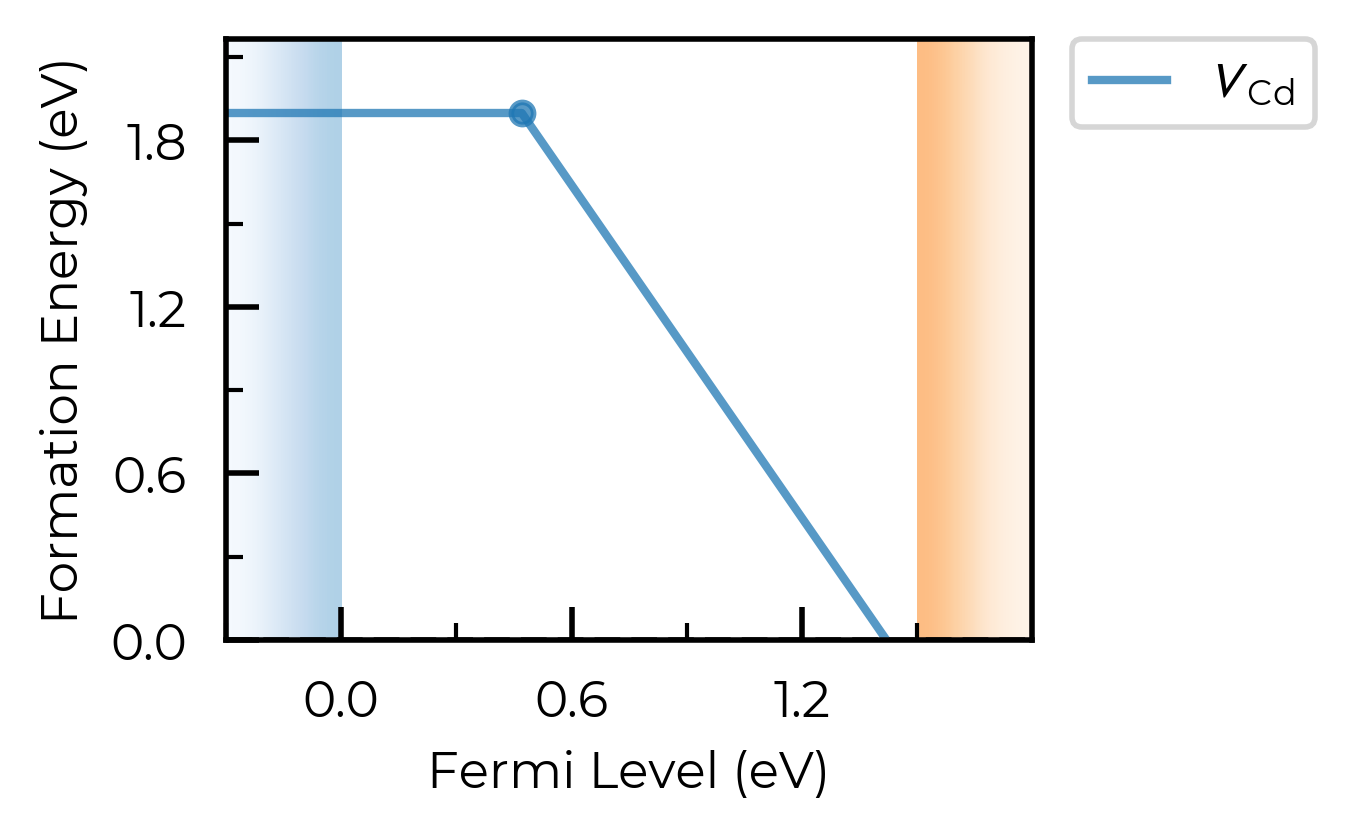

In [25]:
formation_energy_plot = v_Cd_thermo.plot(limit="Te-rich")

### Loading the full CdTe defect thermodynamics

For the rest of this tutorial, we load a pre-parsed `DefectThermodynamics` object containing all intrinsic CdTe point defects (vacancies, antisites and interstitials):

In [26]:
from monty.serialization import loadfn

CdTe_thermo = loadfn("CdTe/CdTe_thermo_wout_meta.json.gz")  # DefectThermodynamics object
CdTe_thermo.chempots = CdTe_chempots  # set chemical potentials for subsequent analyses

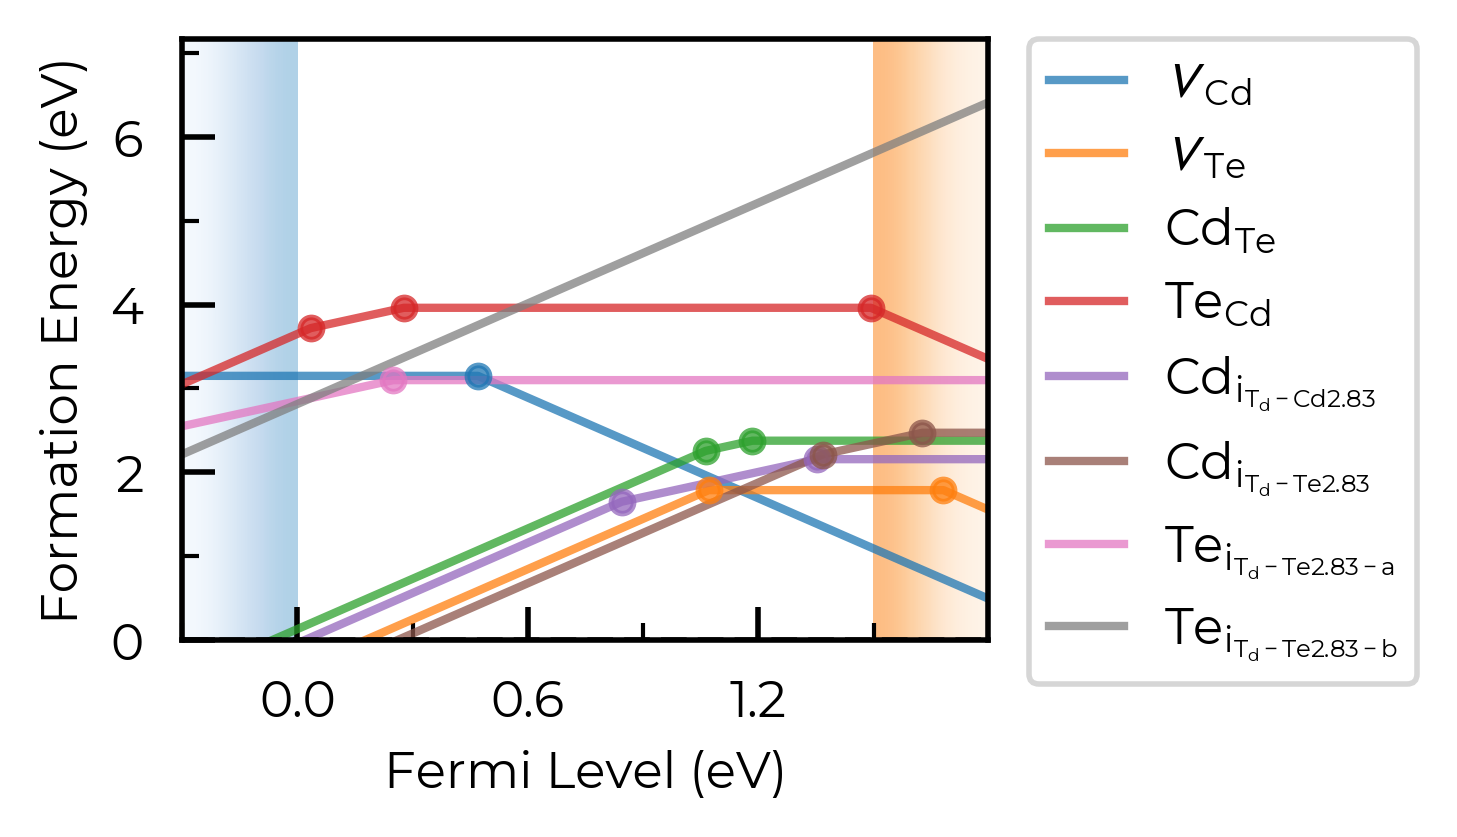

In [28]:
formation_energy_plot = CdTe_thermo.plot(limit="Cd-rich")

## 6. Thermodynamic Analysis

### Equilibrium Fermi Level & Carrier Concentrations

We can solve for the equilibrium Fermi level (at which charge neutrality is satisfied) and get the corresponding carrier concentrations. This requires the bulk electronic density of states (DOS):

In [37]:
vasprun_path = "CdTe/CdTe_prim_k181818_NKRED_2_vasprun.xml.gz"  # bulk DOS calculation

fermi_level, electrons, holes, conc_df = CdTe_thermo.get_fermi_level_and_concentrations(
    bulk_dos=vasprun_path, limit="Te-rich",
    annealing_temperature=900, quenched_temperature=300,  # annealed at 900K, quenched to RT
)  # using frozen defect approximation
print(f"Equilibrium Fermi level: {fermi_level:.3f} eV above VBM")
print(f"Electron concentration:  {electrons:.1e} cm⁻³")
print(f"Hole concentration:      {holes:.1e} cm⁻³")

Equilibrium Fermi level: 0.398 eV above VBM
Electron concentration:  2.6e-02 cm⁻³
Hole concentration:      2.1e+12 cm⁻³


In [41]:
conc_df.head()  # concentration DataFrame

Concentration (cm^-3)  Formation Energy (eV)  \
Defect Charge                                                
v_Cd   0                  1.464e+15                  1.899   
       -1                 7.254e+12                  2.043   
       -2                 9.380e+11                  2.042   
v_Te   +2                 1.789e+08                  1.692   
       +1                 7.349e-14                  2.983   

              Charge State Population Total Concentration (cm^-3)  
Defect Charge                                                      
v_Cd   0                       99.44%                   1.472e+15  
       -1                       0.49%                   1.472e+15  
       -2                       0.06%                   1.472e+15  
v_Te   +2                     100.00%                   1.789e+08  
       +1                       0.00%                   1.789e+08

### Concentration vs Temperature (`FermiSolver`)

The `FermiSolver` class provides powerful tools for scanning defect and carrier concentrations over temperatures, chemical potentials and more. See the [FermiSolver tutorial](https://doped.readthedocs.io/en/latest/fermisolver_tutorial.html) for full details.

In [31]:
from doped.thermodynamics import FermiSolver

fs = FermiSolver(defect_thermodynamics=CdTe_thermo, bulk_dos=vasprun_path)

For example, scanning over temperatures for the Te-rich chemical potential limit:

100%|██████████| 23/23 [00:01<00:00, 18.38it/s]


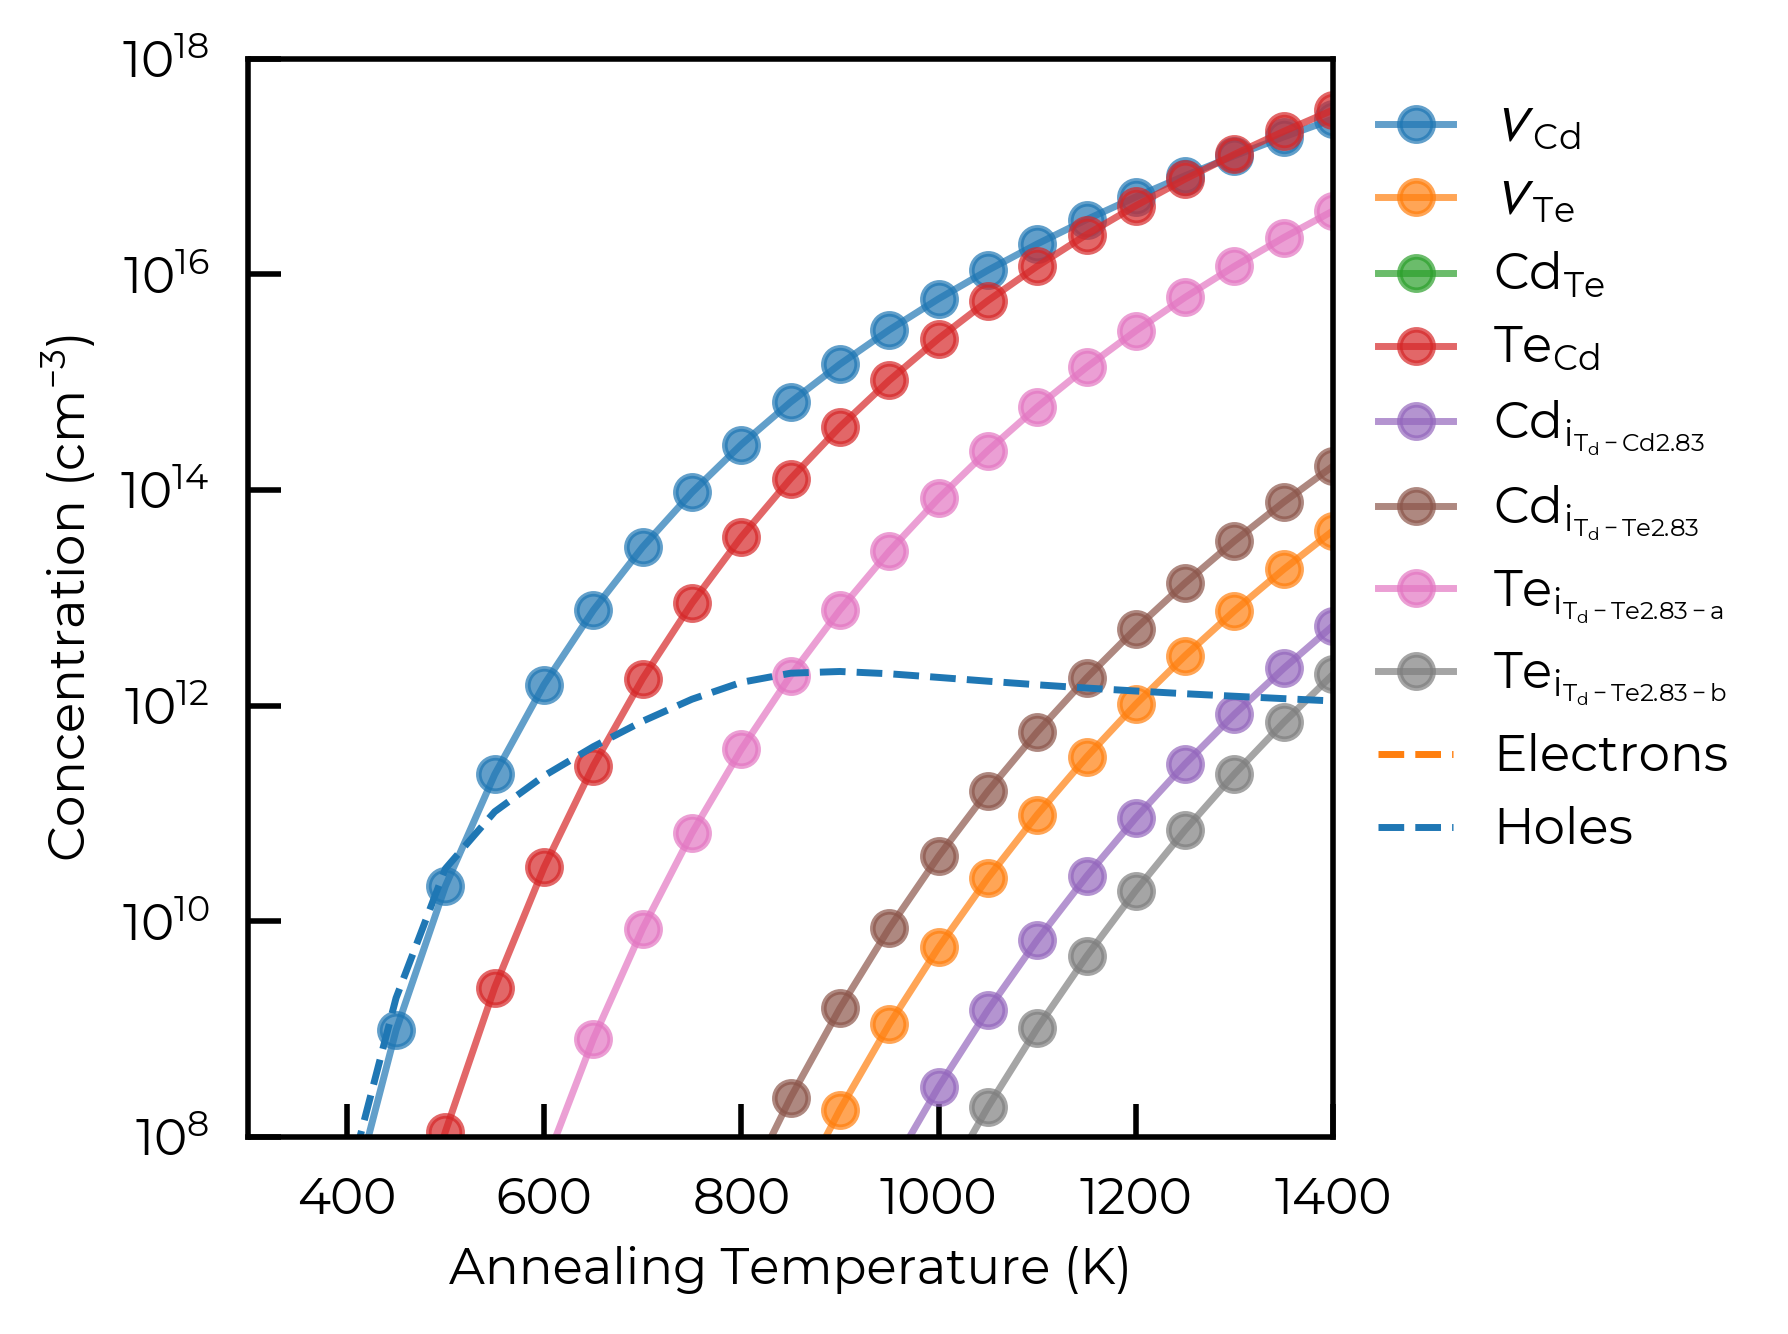

In [44]:
import matplotlib.pyplot as plt
import doped
from doped.utils.plotting import format_defect_name

plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")

temperatures = range(300, 1410, 50)
temp_df = fs.scan_temperature(
    limit="Te-rich", annealing_temperature_range=temperatures, per_charge=False
)  # per_charge=False gives total concentrations per defect species

fig, ax = plt.subplots()
for defect in temp_df.index.unique():
    defect_df = temp_df.loc[defect]
    ax.plot(
        defect_df["Annealing Temperature (K)"],
        defect_df["Concentration (cm^-3)"],
        label=format_defect_name(defect, include_site_info_in_name=True, wout_charge=True),
        marker="o", alpha=0.7,
    )

# also plot carrier concentrations
first_defect_df = temp_df.loc[temp_df.index.unique()[0]]
ax.plot(first_defect_df["Annealing Temperature (K)"], first_defect_df["Electrons (cm^-3)"],
        ls="--", color="C1", label="Electrons")
ax.plot(first_defect_df["Annealing Temperature (K)"], first_defect_df["Holes (cm^-3)"],
        ls="--", color="C0", label="Holes")

ax.set_xlabel("Annealing Temperature (K)")
ax.set_ylabel("Concentration (cm$^{-3}$)")
ax.set_yscale("log")
ax.set_xlim(300, 1400)
ax.set_ylim(1e8, 1e18)
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.show()

### Optimising Chemical Potentials

For a binary like CdTe the chemical potential space is just one-dimensional (Cd-rich ↔ Te-rich), so scanning the optimal growth conditions can be relatively trivial. For more complex multinary systems, the `FermiSolver.optimise()` method can search over the full N-dimensional chemical potential stability region, to find the conditions that maximise or minimise a target property (e.g. carrier or defect concentration). The `scan_chemical_potential_grid()` method similarly allows mapping concentrations over the full accessible chemical potential space. See the [FermiSolver tutorial](https://doped.readthedocs.io/en/latest/fermisolver_tutorial.html) for examples with ternary and higher-order systems.

In [ ]:
# find the chemical potentials that maximise hole concentration, under the given μ/T conditions
max_holes_df = fs.optimise(
    target="Holes (cm^-3)",
    min_or_max="max",
    annealing_temperature=900,
    quenched_temperature=300,
)
max_holes_df.head()

100%|██████████| 30/30 [00:01<00:00, 19.99it/s]


Searching for chemical potentials which maximise the target column: ['Holes (cm^-3)']...


100%|██████████| 30/30 [00:01<00:00, 19.69it/s]


Concentration (cm^-3)  Formation Energy (eV)  \
Defect Charge                                                 
v_Cd    0               8.472106e+14                  2.006   
       -1               2.988532e+12                  2.160   
       -2               2.750703e+11                  2.168   
v_Te    2               3.064684e+08                  1.567   
        1               8.959544e-14                  2.866   

              Charge State Population  Total Concentration (cm^-3)  \
Defect Charge                                                        
v_Cd    0                      99.62%                 8.504742e+14   
       -1                       0.35%                 8.504742e+14   
       -2                       0.03%                 8.504742e+14   
v_Te    2                     100.00%                 3.064684e+08   
        1                       0.00%                 3.064684e+08   

               Annealing Temperature (K)  Quenched Temperature (K)  \
Defect Charge                                                        
v_Cd    0                            900                       300   
       -1                            900                       300   
       -2                            900                       300   
v_Te    2                            900                       300   
        1                            900                       300   

               Fermi Level (eV wrt VBM)  Electrons (cm^-3)  Holes (cm^-3)  \
Defect Charge                                                               
v_Cd    0                      0.389213           0.018808   2.917748e+12   
       -1                      0.389213           0.018808   2.917748e+12   
       -2                      0.389213           0.018808   2.917748e+12   
v_Te    2                      0.389213           0.018808   2.917748e+12   
        1                      0.389213           0.018808   2.917748e+12   

               μ_Cd (eV)  μ_Te (eV)  
Defect Charge                        
v_Cd    0      -1.143445  -0.107872  
       -1      -1.143445  -0.107872  
       -2      -1.143445  -0.107872  
v_Te    2      -1.143445  -0.107872  
        1      -1.143445  -0.107872

## Summary & Further Resources

This tutorial covered the barebones core `doped` workflow. For more detail on each step, and for additional analyses, see the dedicated tutorials:

| Topic | Tutorial |
|-------|----------|
| Defect generation, ShakeNBreak & input files | [Generation tutorial](https://doped.readthedocs.io/en/latest/generation_tutorial.html) |
| Parsing calculations & finite-size charge corrections | [Parsing tutorial](https://doped.readthedocs.io/en/latest/parsing_tutorial.html) |
| Chemical potential limits & competing phases | [Chemical potentials tutorial](https://doped.readthedocs.io/en/latest/chemical_potentials_tutorial.html) |
| Defect thermodynamics, symmetries & doping windows | [Thermodynamics tutorial](https://doped.readthedocs.io/en/latest/thermodynamics_tutorial.html) |
| Advanced Fermi level & concentration scanning | [FermiSolver tutorial](https://doped.readthedocs.io/en/latest/fermisolver_tutorial.html) |
| Customising publication-quality plots | [Plotting customisation tutorial](https://doped.readthedocs.io/en/latest/plotting_customisation_tutorial.html) |
| Comprehensive defect simulation workflow | [GGA workflow tutorial](https://doped.readthedocs.io/en/latest/GGA_workflow_tutorial.html) |
| Configuration coordinate diagrams & non-radiative recombination setup | [CCD/NEB tutorial](https://doped.readthedocs.io/en/latest/CCD_NEB_tutorial.html) |
| Defect structure stenciling | [Stenciling tutorial](https://doped.readthedocs.io/en/latest/stenciling_tutorial.html) |
| Full API reference | [Code documentation](https://doped.readthedocs.io/en/latest/doped.html) |
| Tips & tricks for defect calculations | [Tips](https://doped.readthedocs.io/en/latest/Tips.html) |

```{tip}
If you use `doped` in your research, please cite the code paper:
[JOSS (2024)](https://doi.org/10.21105/joss.06433).
```